<!--
(C) Copyright 1996- ECMWF.

This software is licensed under the terms of the Apache Licence Version 2.0
which can be obtained at http://www.apache.org/licenses/LICENSE-2.0.
In applying this licence, ECMWF does not waive the privileges and immunities
granted to it by virtue of its status as an intergovernmental organisation
nor does it submit to any jurisdiction.
-->

# thermofeel &times; earthkit &mdash; thermal-comfort indices from ECMWF open data

[**thermofeel**](https://github.com/ecmwf/thermofeel) is a pure-`numpy` library
that computes human **thermal-comfort indices** (Universal Thermal Climate Index,
apparent temperature, humidex, heat index, wet-bulb globe temperature, wind
chill, &hellip;) from meteorological fields.

This notebook is a small, self-contained demo built entirely on the
[**earthkit**](https://earthkit.readthedocs.io) stack:

- **earthkit-data** pulls a recent forecast from the **ECMWF open data** service
  &mdash; no login or API key required (data is CC-BY-4.0);
- **thermofeel** + **earthkit-meteo** turn the raw fields into comfort indices;
- **earthkit-plots** draws the maps &mdash; this replaces the old
  Magics / metview / seaborn plotting code.

### What open data can (and cannot) do

The free open-data feed ships the surface analysis/forecast fields but **not** the
radiation components &mdash; notably the direct solar radiation `fdir` &mdash;
that the radiation-based indices need. So this demo sticks to the
**humidity/wind indices** (apparent temperature, heat index, humidex, discomfort
index), which need only `2t`, `2d`, `10u` and `10v`.

The radiation indices (**UTCI**, **mean radiant temperature**, WBGT) require an
authenticated, radiation-complete source. The companion script
[`examples/compute-thermal-indices.py`](./compute-thermal-indices.py) is built for
that &mdash; see its `--source polytope` / `--source mars` options and the
`--approximate-fdir` fallback &mdash; and
[`examples/compute-obs.py`](./compute-obs.py) computes indices from station
observations. Pointers to both are collected at the end.

In [1]:
# Core scientific stack
import numpy as np

# earthkit: data access, meteorological helpers and plotting
import earthkit.data as ekd
import earthkit.meteo as ekm
from earthkit.meteo import wind

import earthkit.plots as ekp

# thermofeel: the thermal-comfort indices themselves
import thermofeel as tf

# requests: only used for the optional METAR station overlay near the end
import requests

# matplotlib is earthkit-plots' rendering backend; we only touch it to display
# each chart deterministically when the notebook is run head-less (nbconvert).
import io

import matplotlib.pyplot as plt
from IPython.display import Image, display


def show(chart, dpi=85):
    '''Render an earthkit-plots chart to an inline PNG, then close its figure.

    Rendering explicitly - rather than leaning on matplotlib's implicit
    end-of-cell display - keeps `jupyter nbconvert` output reproducible (it also
    works for cells that add a scatter overlay) and keeps the embedded images
    light. The crisp copies are still written to disk by `chart.save(...)`.
    '''
    buffer = io.BytesIO()
    chart.fig.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    plt.close(chart.fig)
    display(Image(data=buffer.getvalue()))


print("thermofeel    ", tf.__version__)
print("earthkit-data ", ekd.__version__)
print("earthkit-meteo", ekm.__version__)
print("earthkit-plots", ekp.__version__)
print("numpy         ", np.__version__)

thermofeel     2.3.0
earthkit-data  1.0.2
earthkit-meteo 1.0.0
earthkit-plots 1.0.2
numpy          2.5.1


## 1. Fetch a recent forecast from ECMWF open data

`earthkit.data.from_source("ecmwf-open-data", ...)` wraps the
[`ecmwf-opendata`](https://github.com/ecmwf/ecmwf-opendata) client, which always
resolves to the **latest available HRES run** &mdash; so we never hard-code a
date. We request the four surface fields the humidity/wind indices depend on:

| shortName | meaning            | units |
|-----------|--------------------|-------|
| `2t`      | 2&nbsp;m temperature | K     |
| `2d`      | 2&nbsp;m dewpoint    | K     |
| `10u`     | 10&nbsp;m U-wind     | m/s   |
| `10v`     | 10&nbsp;m V-wind     | m/s   |

In [2]:
request = dict(
    type="fc",
    stream="oper",
    levtype="sfc",
    step=12,
    param=["2t", "2d", "10u", "10v"],
)

ds = ekd.from_source("ecmwf-open-data", request=request)
fl = ds.to_fieldlist()

# This build of earthkit-data doesn't carry a working `.sel()` for open-data
# GRIB, so we index the fields by their GRIB shortName instead.
fields = {f.metadata("shortName"): f for f in fl}

# Field values -> 2-D numpy arrays (Kelvin for 2t/2d, m/s for the winds).
t2m = fields["2t"].to_numpy()    # [K]
d2m = fields["2d"].to_numpy()    # [K]
u10 = fields["10u"].to_numpy()   # [m/s]
v10 = fields["10v"].to_numpy()   # [m/s]

# Coordinates: earthkit-data 1.0 exposes lat/lon through `field.geography`
# (the older `field.to_latlon()` is gone); `.latlons()` returns 2-D meshgrids.
lat2d, lon2d = fields["2t"].geography.latlons()

base = fields["2t"].metadata("base_datetime")
valid = fields["2t"].metadata("valid_datetime")
print(f"run       : {base}")
print(f"valid     : {valid}  (step {fields['2t'].metadata('step')} h)")
print(f"grid      : {t2m.shape}  (global regular lat/lon, 0.25 deg)")
print(f"lat range : {lat2d.min():6.2f} ... {lat2d.max():6.2f}")
print(f"lon range : {lon2d.min():6.2f} ... {lon2d.max():6.2f}")

To ensure the stability of our systems and to preserve resources for our operational activities (network, compute, etc.), access to the open-data portal is limited to 500 simultaneous connections. This limit helps us guarantee reliable service for our operational users, especially during periods of high demand. For added reliability, the open-data is replicated across AWS, Azure, and Google Cloud. If you experience difficulties accessing the portal directly, you can also retrieve the data from these cloud platforms.


<multiple>:   0%|          | 0.00/2.92M [00:00<?, ?B/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


run       : 2026-07-04 12:00:00
valid     : 2026-07-05 00:00:00  (step 12 h)
grid      : (721, 1440)  (global regular lat/lon, 0.25 deg)
lat range : -90.00 ...  90.00
lon range : -180.00 ... 179.75


## 2. Compute thermal-comfort indices

thermofeel works directly on the gridded `numpy` arrays and expects temperatures
in **Kelvin**. We first derive the two quantities several indices share:

- **wind speed** from the U/V components, via `earthkit.meteo.wind.speed`;
- **relative humidity** from temperature + dewpoint, via
  `thermofeel.calculate_relative_humidity_percent`.

Then we compute four indices for variety &mdash; **apparent temperature**
(Steadman, needs `2t` + wind + RH), **heat index (adjusted)**, **humidex** and
**Thom's discomfort index**. Each `calculate_*` returns Kelvin, which we convert
to &deg;C for display. These are heat-stress indices, so their values are most
meaningful in warm conditions (the global min/max below include polar cold).

In [3]:
# Shared inputs.
ws = wind.speed(u10, v10)                                        # [m/s]
rh = tf.calculate_relative_humidity_percent(t2_k=t2m, td_k=d2m)  # [%]

# Indices (thermofeel returns Kelvin -> convert to Celsius for display).
to_c = tf.kelvin_to_celsius
apparent_c   = to_c(tf.calculate_apparent_temperature(t2_k=t2m, va=ws, rh=rh))
heatindex_c  = to_c(tf.calculate_heat_index_adjusted(t2_k=t2m, td_k=d2m))
humidex_c    = to_c(tf.calculate_humidex(t2_k=t2m, td_k=d2m))
discomfort_c = to_c(tf.calculate_discomfort_index(t2_k=t2m, rh=rh))

print(f"{'field':26s} {'min':>8s} {'mean':>8s} {'max':>8s}")
print("-" * 52)
for name, arr in [
    ("2 m temperature [C]", to_c(t2m)),
    ("relative humidity [%]", rh),
    ("wind speed [m/s]", ws),
    ("apparent temperature [C]", apparent_c),
    ("heat index adjusted [C]", heatindex_c),
    ("humidex [C]", humidex_c),
    ("discomfort index [C]", discomfort_c),
]:
    print(f"{name:26s} {np.nanmin(arr):8.1f} {np.nanmean(arr):8.1f} {np.nanmax(arr):8.1f}")

field                           min     mean      max
----------------------------------------------------
2 m temperature [C]           -67.0      8.3     42.8
relative humidity [%]           2.7     76.3    100.0
wind speed [m/s]                0.0      6.4     29.9
apparent temperature [C]      -75.0      4.3     42.9
heat index adjusted [C]       -67.0      8.7     53.3
humidex [C]                   -72.6     10.3     53.1
discomfort index [C]          -67.0      9.1     32.0


## 3. Map the indices with earthkit-plots

`earthkit-plots` is the modern replacement for Magics. There are two entry
points:

- `ekp.quickplot(field, domain="Europe", units="celsius")` &mdash; a one-liner
  straight from an earthkit-data *field*, ideal for a quick look at an input;
- `ekp.Map(domain=...)` + `.contourf(...)` &mdash; full control, and the natural
  fit for our derived indices, which are plain `numpy` arrays. We hand the array
  plus the `lon2d`/`lat2d` meshgrids to `.contourf`, and describe the values with
  `metadata={"units": "celsius", ...}` so the colour bar is labelled correctly.

`domain="Europe"` clips the global field to Europe; `coastlines`, `borders`,
`gridlines`, `legend` and `title` add the usual map furniture. Figures are also
saved as PNGs next to the notebook (git-ignored).

Finally, as an **optional** extra, we pull a handful of recent **METARs** from
NOAA's Aviation Weather API (`aviationweather.gov`, no auth), compute the
apparent temperature per station with thermofeel, and overlay them on the model
field with `chart.scatter(..., z=values)` &mdash; same colour scale, so a
well-matched station blends into the background. The fetch is wrapped in
`try/except` so a transient API hiccup can't break the notebook.

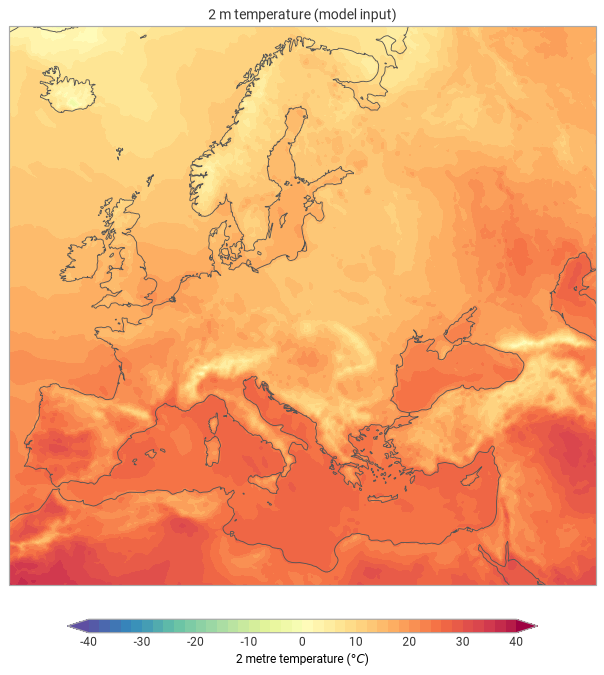

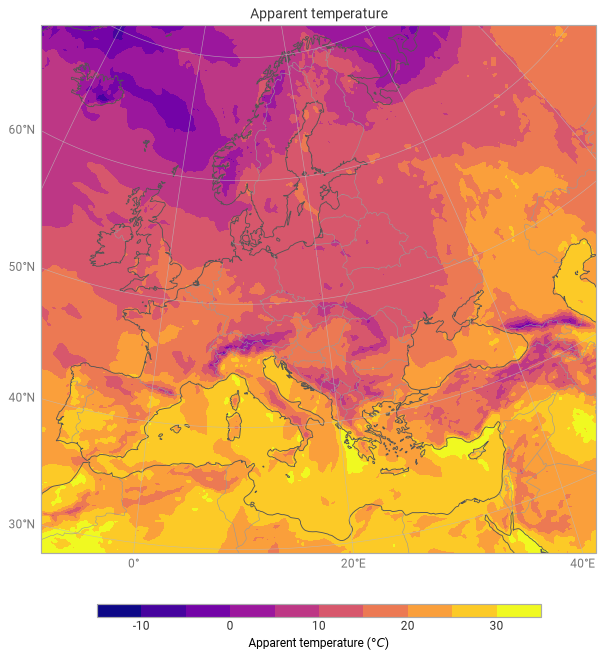

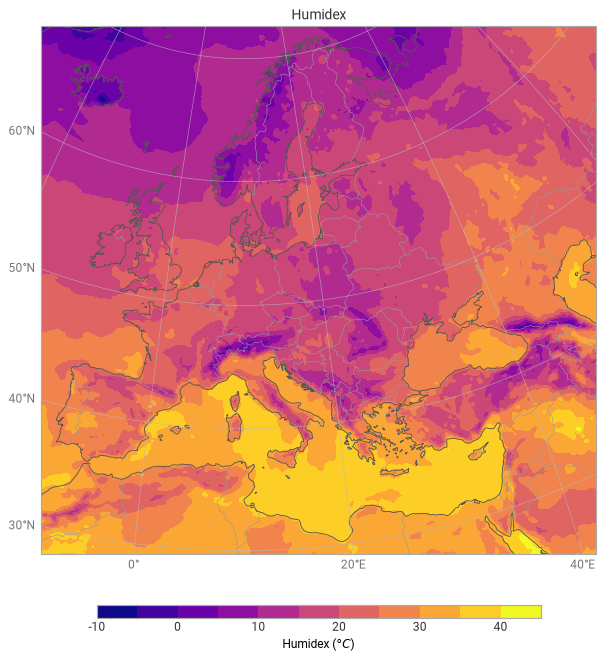

In [4]:
# (1) One-liner straight from an earthkit-data field: the 2 m temperature input.
qp = ekp.quickplot(fields["2t"], domain="Europe", units="celsius")
qp.title("2 m temperature (model input)")
qp.save("t2m_input.png", dpi=150)
show(qp)


# (2) Full control: build a Map and contour a thermofeel index (already in C).
def index_map(values_c, long_name, filename):
    chart = ekp.Map(domain="Europe")
    chart.contourf(
        values_c,
        x=lon2d,
        y=lat2d,
        metadata={"units": "celsius", "long_name": long_name},
    )
    chart.coastlines()
    chart.borders()
    chart.gridlines()
    chart.legend()
    chart.title(long_name)
    chart.save(filename, dpi=150)
    return chart


show(index_map(apparent_c, "Apparent temperature", "apparent_temperature.png"))
show(index_map(humidex_c, "Humidex", "humidex.png"))

14 stations: LEMD=29C, LPPT=24C, LEBL=26C, LFPG=23C, EIDW=14C, EHAM=19C, EDDF=22C, ESSA=14C, LSZH=19C, LIRF=27C, EGLL=19C, EKCH=13C, LOWW=17C, LGAV=25C


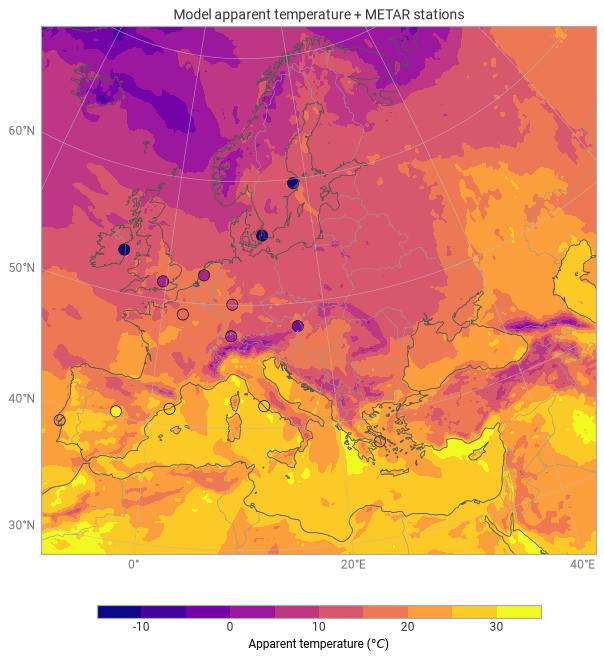

In [5]:
# Optional: overlay live METAR station observations on the model field.
STATIONS = "EGLL,LFPG,EDDF,EHAM,LEMD,LIRF,LSZH,LOWW,EKCH,ESSA,LEBL,EIDW,LPPT,LGAV"
url = f"https://aviationweather.gov/api/data/metar?ids={STATIONS}&format=json&hours=3"

s_lon, s_lat, s_at, s_id = [], [], [], []
try:
    reports = requests.get(url, timeout=30).json()
    latest = {}  # keep the most recent report per station
    for m in reports:
        if m.get("temp") is None or m.get("dewp") is None:
            continue
        k = m["icaoId"]
        if k not in latest or (m.get("obsTime") or 0) > latest[k].get("obsTime", 0):
            latest[k] = m
    for k, m in latest.items():
        t_k = tf.celsius_to_kelvin(float(m["temp"]))
        td_k = tf.celsius_to_kelvin(float(m["dewp"]))
        va = float(m.get("wspd") or 0.0) * 0.514444  # knots -> m/s
        rh_s = tf.calculate_relative_humidity_percent(t2_k=t_k, td_k=td_k)
        at_s = tf.calculate_apparent_temperature(t2_k=t_k, va=va, rh=rh_s)
        s_lon.append(float(m["lon"]))
        s_lat.append(float(m["lat"]))
        s_at.append(float(tf.kelvin_to_celsius(at_s)))
        s_id.append(k)
    print(f"{len(s_id)} stations: " + ", ".join(f"{i}={v:.0f}C" for i, v in zip(s_id, s_at)))
except Exception as exc:  # keep the notebook runnable if the API is unreachable
    print(f"METAR fetch skipped ({exc!r})")

chart = ekp.Map(domain="Europe")
chart.contourf(
    apparent_c,
    x=lon2d,
    y=lat2d,
    metadata={"units": "celsius", "long_name": "Apparent temperature"},
)
if s_id:
    chart.scatter(
        x=np.array(s_lon),
        y=np.array(s_lat),
        z=np.array(s_at),
        metadata={"units": "celsius", "long_name": "Station apparent temperature"},
        s=90,
        edgecolors="black",
        linewidths=0.6,
    )
chart.coastlines()
chart.borders()
chart.gridlines()
chart.legend()
chart.title("Model apparent temperature + METAR stations")
chart.save("apparent_temperature_stations.png", dpi=150)
show(chart)

## Where to go next

- **Radiation-based indices (UTCI, MRT, WBGT).** These need the surface radiation
  fields (`ssrd`, `ssr`, `fdir`, `strd`, `str`, &hellip;) that ECMWF open data
  doesn't publish. The example script
  [`compute-thermal-indices.py`](./compute-thermal-indices.py) reads a
  radiation-complete source &mdash; see its `--source polytope` / `--source mars`
  options (install the optional `polytope-client` / `ecmwf-api-client` backends
  from the `thermofeel[examples]` extra), plus `--approximate-fdir` for when the
  direct radiation is missing &mdash; and encodes every index back to GRIB.
- **Station / observation workflows.**
  [`compute-obs.py`](./compute-obs.py) computes indices (MRT, WBGT, &hellip;) from
  BSRN-style station observations, using `earthkit.meteo.solar` for the solar
  geometry.
- **The full index set.** See the
  [thermofeel docs](https://thermofeel.readthedocs.io) for UTCI, wet-bulb globe
  temperature (including the Liljegren method), wind chill, PMV/PPD, the KNMI heat
  force scale and the excess-heat / excess-cold factors.

_This notebook writes its maps as PNG files next to itself; those are git-ignored._